
════════════════════════════════════════════════════════════════════════════════
SELECTION OF METHOD FOR TAIL HANDLING / UNCERTAINTY
════════════════════════════════════════════════════════════════════════════════
1 → Ad-hoc marginal extension (simple and fast)
2 → Ad-hoc extension + bootstrap uncertainty bands
3 → Bootstrap uncertainty bands only (more robust)

Choose method (1, 2 or 3) [default 1]: 2
→ Selected method: 2


════════════════════════════════════════════════════════════════════════════════
CASE 1 – Original simulated model
════════════════════════════════════════════════════════════════════════════════
Original model → lengths OK: n = 1000
Original simulated    n = 1000   τ = -0.7652   θ_Frank =  -15.189


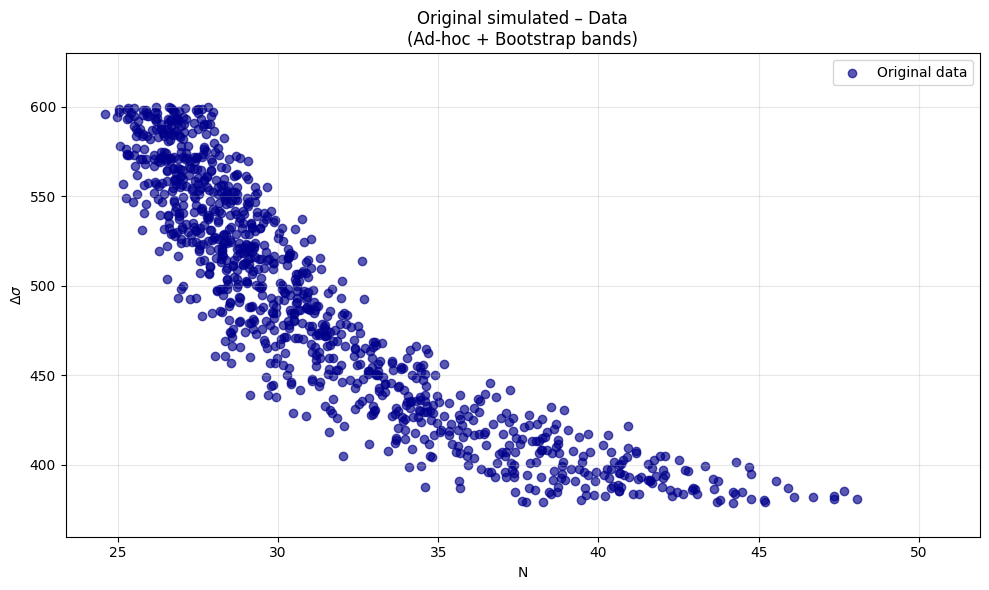

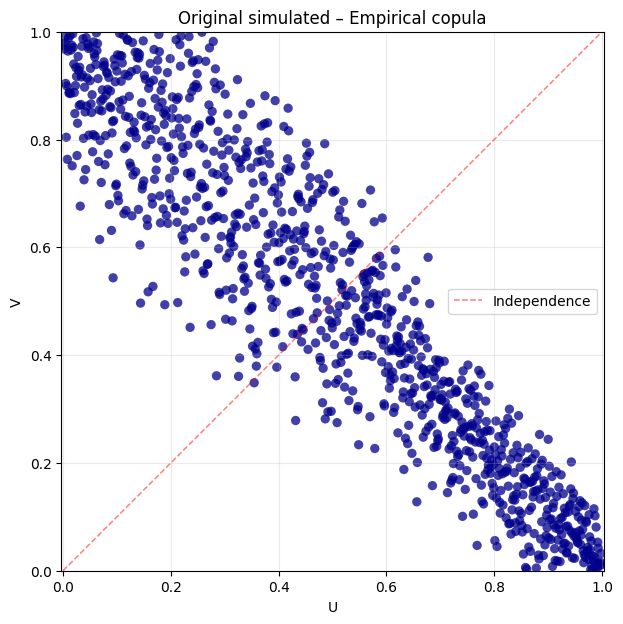

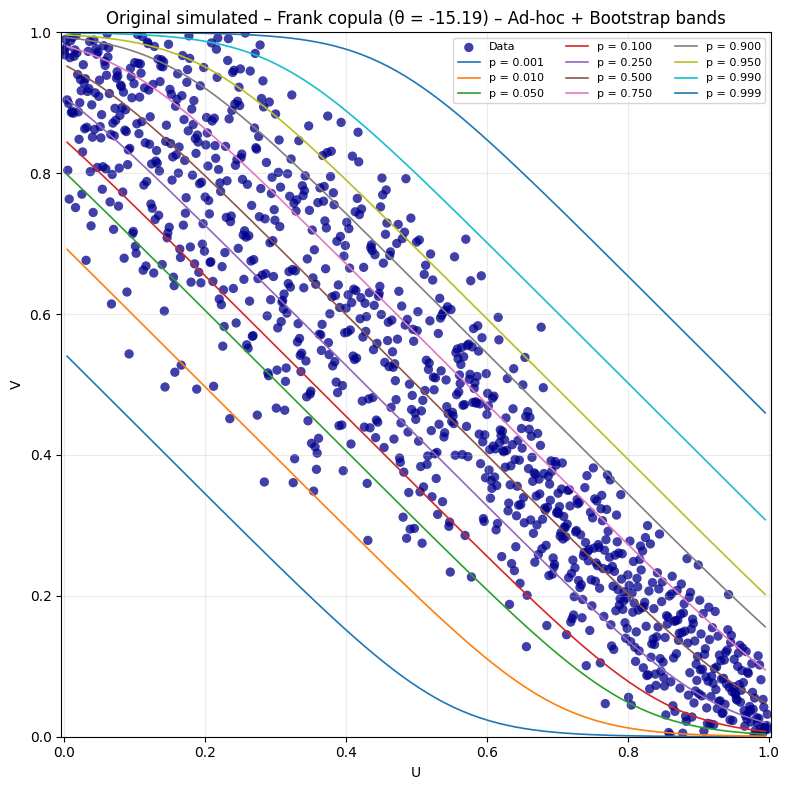

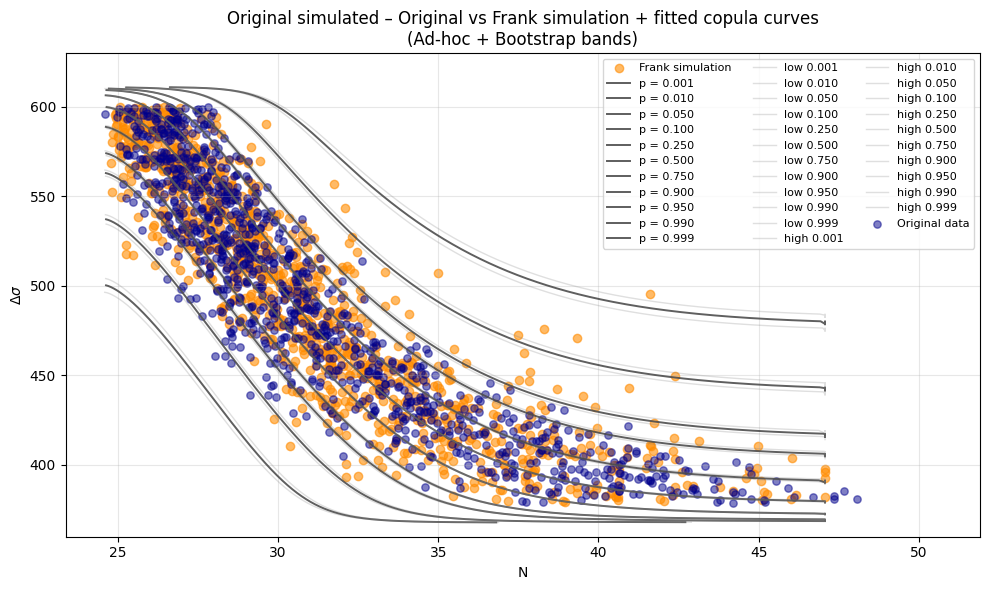


════════════════════════════════════════════════════════════════════════════════
CASE 2 – Beta simulated model
════════════════════════════════════════════════════════════════════════════════
Beta model → lengths OK: n = 1000
Estimated Beta parameters: alpha=0.20, beta=0.34
   Note: For Beta case → forced method 3 (bootstrap)
Beta simulated (parametric)  n = 1000   τ = -0.8713   θ_Frank =  -29.329


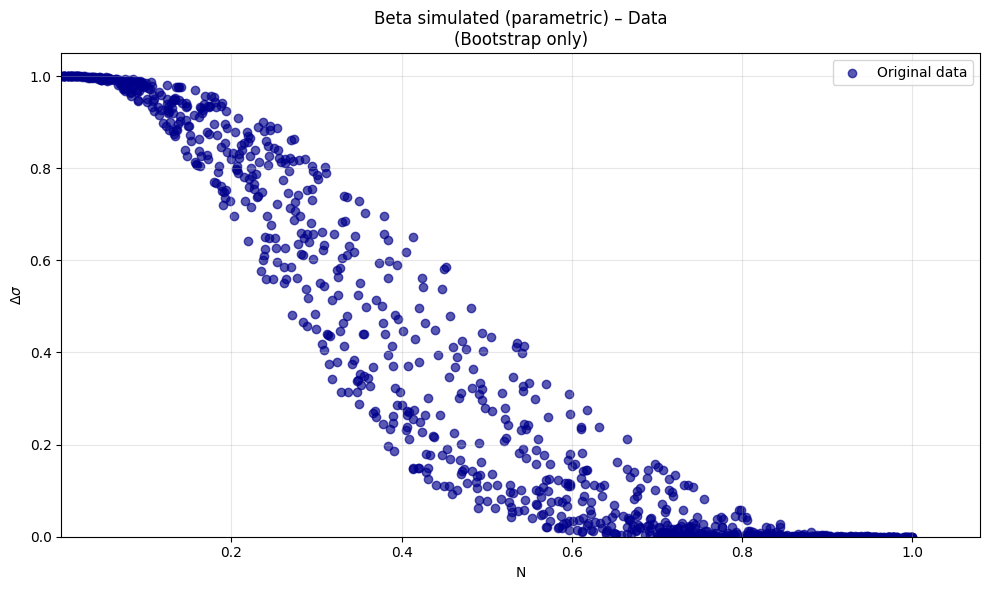

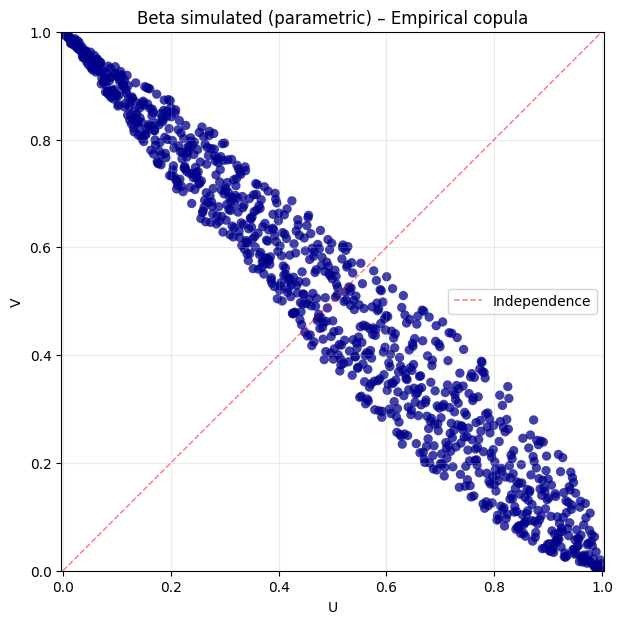

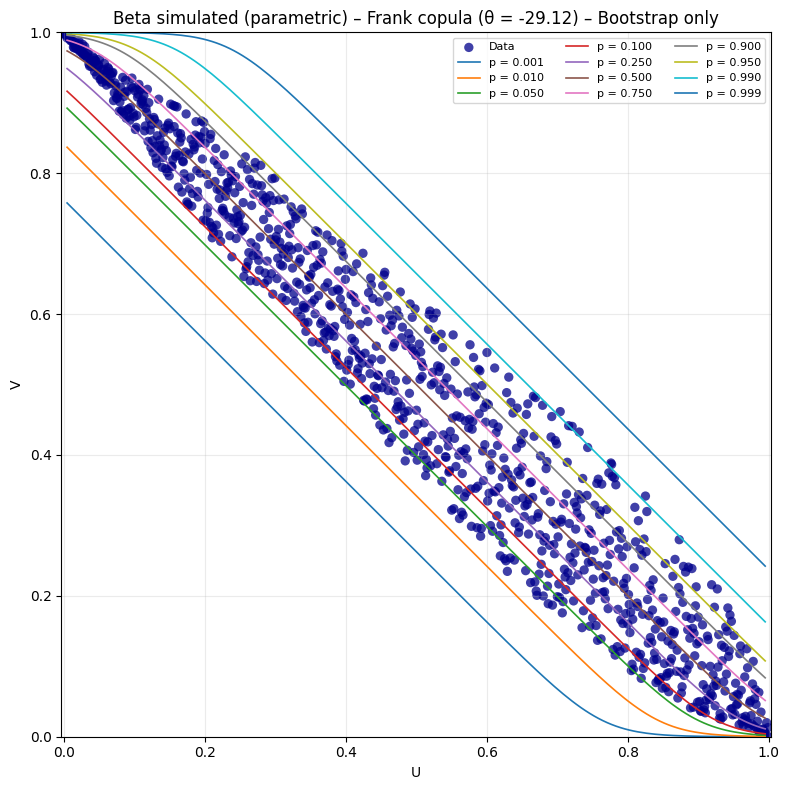

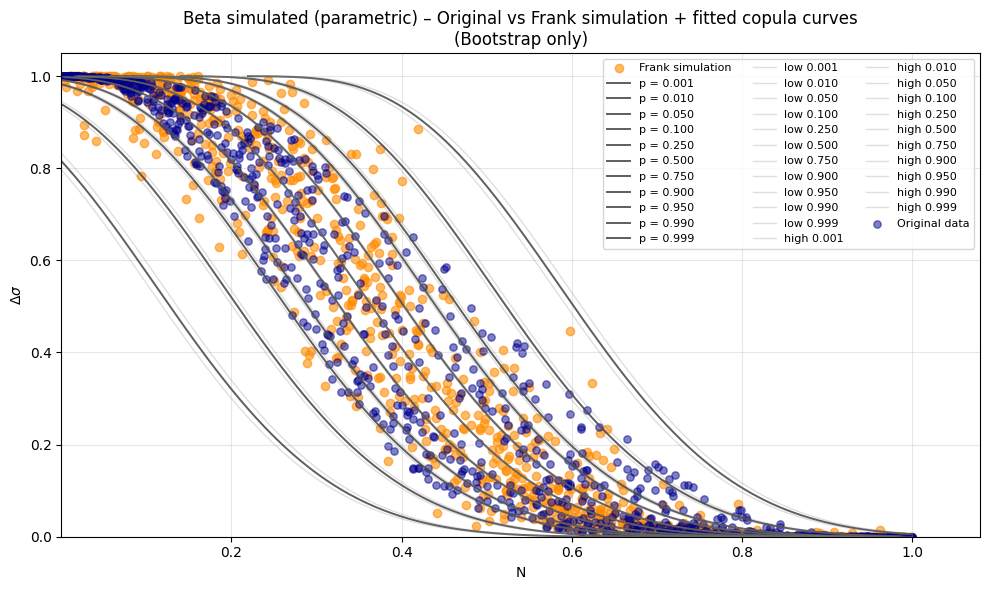


════════════════════════════════════════════════════════════════════════════════
CASE 3 – HOLMEN real data
════════════════════════════════════════════════════════════════════════════════
HOLMEN → lengths OK: n = 75
HOLMEN real           n =   75   τ = -0.8234   θ_Frank =  -20.867


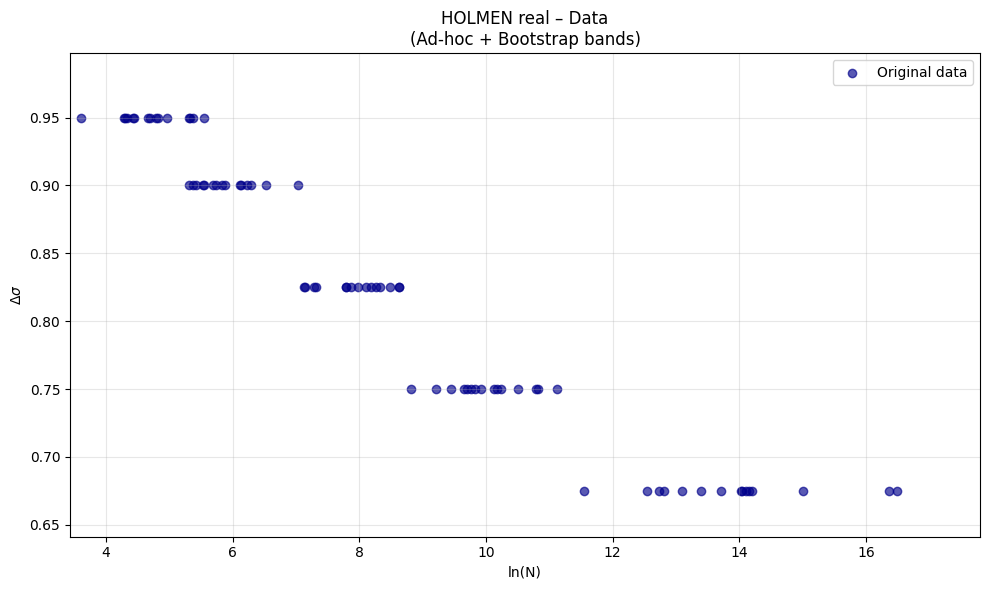

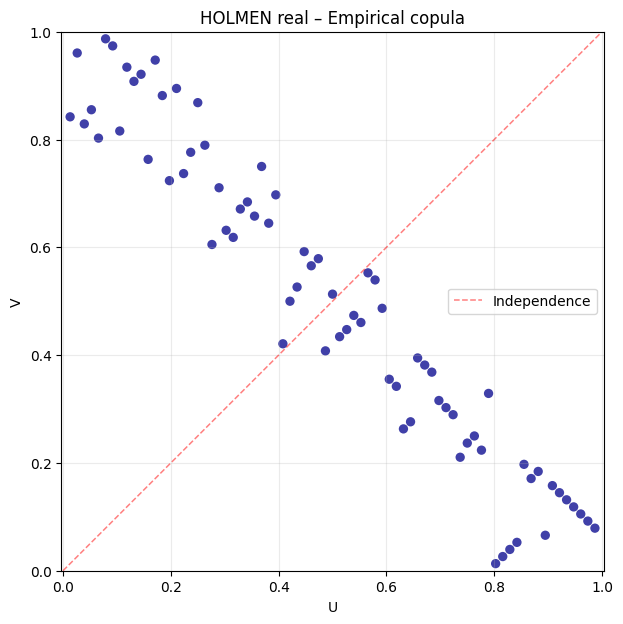

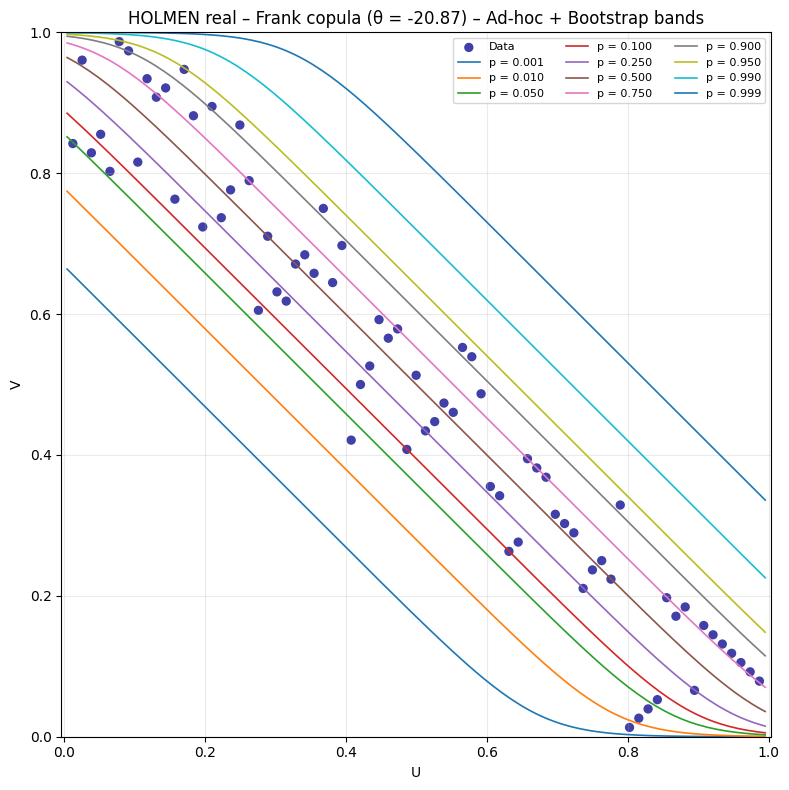

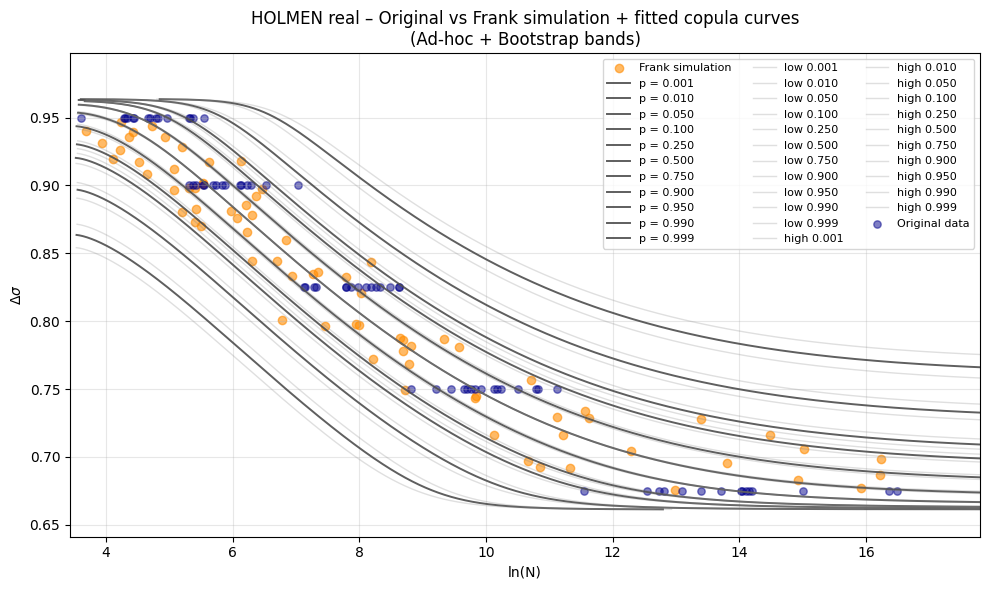


════════════════════════════════════════════════════════════════════════════════
CASE 4 – MAENNIG real data
════════════════════════════════════════════════════════════════════════════════
MAENNIG → lengths OK: n = 360
MAENNIG real          n =  360   τ = -0.6398   θ_Frank =   -9.099


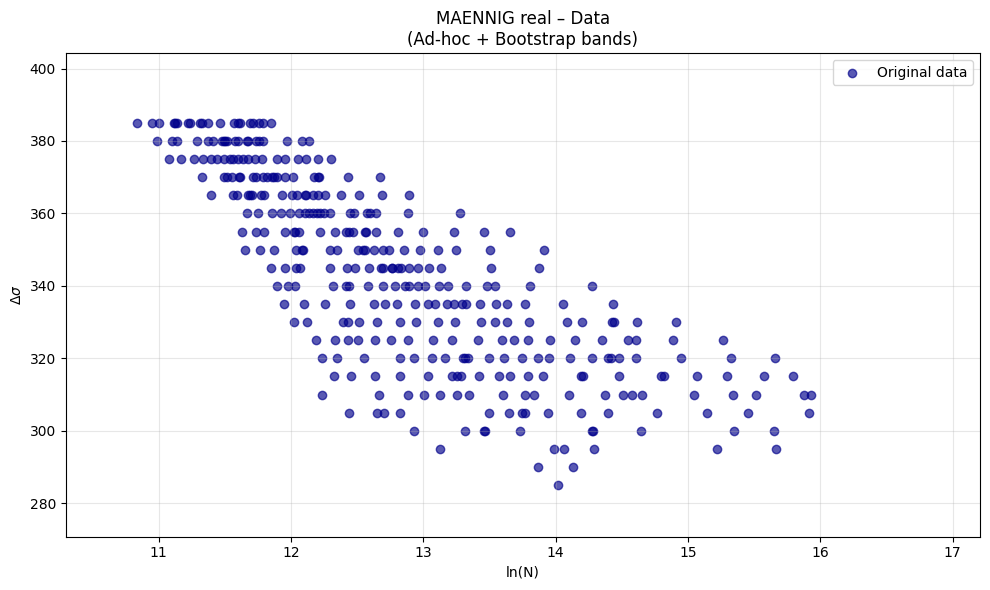

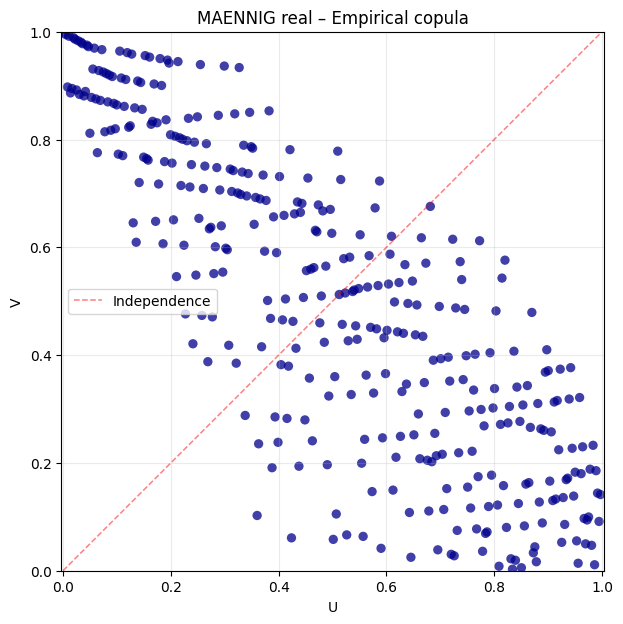

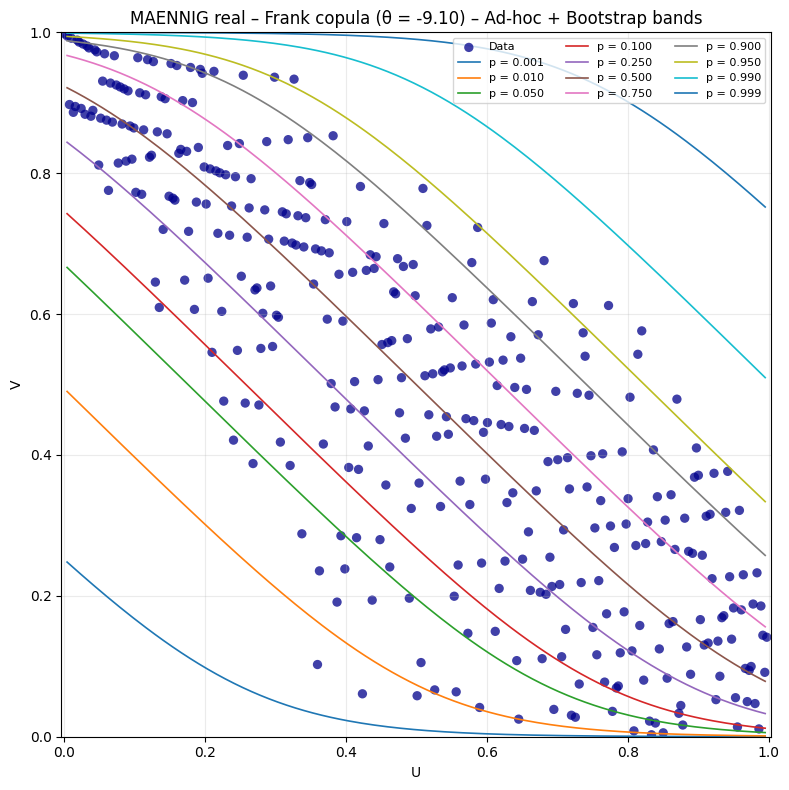

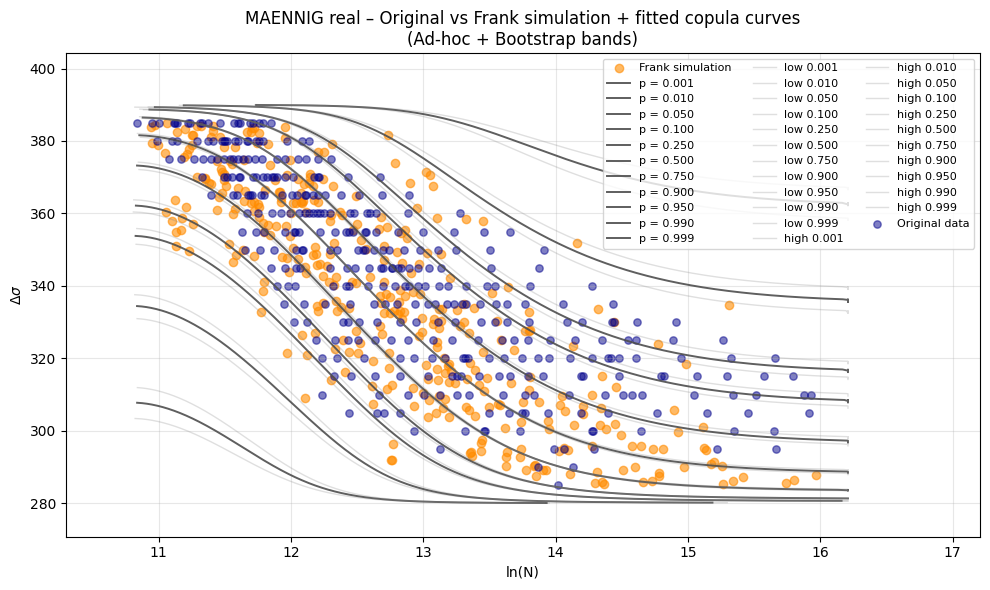


════════════════════════════════════════════════════════════════════════════════
Processing finished – all figures generated
════════════════════════════════════════════════════════════════════════════════


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
# VERSION A9c – CORRECTED WITH THREE OPTIONS
# 1: Ad-hoc extension
# 2: Ad-hoc + bootstrap uncertainty bands
# 3: Bootstrap uncertainty bands only

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist, kendalltau, weibull_min, uniform
from scipy.optimize import brentq
from scipy.integrate import quad
import os
from google.colab import files

# ──────────────────────────────────────────────────────────────────────────────
# METHOD SELECTION: now with 3 options
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "═"*80)
print("SELECTION OF METHOD FOR TAIL HANDLING / UNCERTAINTY")
print("═"*80)
print("1 → Ad-hoc marginal extension (simple and fast)")
print("2 → Ad-hoc extension + bootstrap uncertainty bands")
print("3 → Bootstrap uncertainty bands only (more robust)")
print("")

while True:
    try:
        entrada = input("Choose method (1, 2 or 3) [default 1]: ").strip()
        if entrada == "":
            method_choice = 1
            print("→ Default method: 1 (ad-hoc extension)")
            break
        method_choice = int(entrada)
        if method_choice in [1, 2, 3]:
            print(f"→ Selected method: {method_choice}")
            break
        else:
            print("Please enter 1, 2 or 3.")
    except ValueError:
        print("Invalid input. Enter 1, 2 or 3 (or press Enter for default).")

print("")

# Configurable parameters
margin_factor = 0.05       # For methods 1 and 2: 5% extra per tail
n_boot = 100               # For methods 2 and 3: number of bootstrap resamples

# ──────────────────────────────────────────────────────────────────────────────
# Create output folder
# ──────────────────────────────────────────────────────────────────────────────
os.makedirs('/content/FIGURES', exist_ok=True)

# ──────────────────────────────────────────────────────────────────────────────
# Helper functions
# ──────────────────────────────────────────────────────────────────────────────

def check_lengths(N, Delta, name="dataset"):
    if len(N) != len(Delta):
        raise ValueError(f"ERROR: {name} – lengths differ\n  len(N)     = {len(N)}\n  len(Delta) = {len(Delta)}")
    print(f"{name} → lengths OK: n = {len(N)}")


def ranks_to_uniform(data, method='i/(n+1)'):
    n = len(data)
    ranks = np.argsort(np.argsort(data)) + 1
    if method == 'i/(n+1)':
        return ranks / (n + 1)
    raise ValueError("Only 'i/(n+1)' method supported")


def conditional_quantile_frank(w, cond, theta):
    if abs(theta) < 1e-6:
        return w
    emt = np.exp(-theta)
    emtc = np.exp(-theta * cond)
    num = (emt - 1) * w
    den = emtc - w * (emtc - 1)
    with np.errstate(divide='ignore', invalid='ignore'):
        frac = num / den
        arg = 1 + frac
        arg = np.where(arg > 0, arg, np.nan)
        return -np.log(arg) / theta


def inverse_conditional_u_frank(p, v, theta):
    if abs(theta) < 1e-6:
        return np.nan if abs(v - p) > 1e-6 else 0.5
    emt = np.exp(-theta)
    emtv = np.exp(-theta * v)
    num = p * (emt - emtv)
    den = (1 - p) * (emtv - 1)
    with np.errstate(divide='ignore', invalid='ignore'):
        b = num / den
        b = np.where(b > 0, b, np.nan)
        return -np.log(b) / theta


def find_frank_theta(tau):
    if abs(tau) < 1e-6:
        return 0.0

    def frank_tau_func(theta):
        if abs(theta) < 1e-6:
            return 0.0
        at = abs(theta)
        int_val, _ = quad(lambda t: t / (np.exp(t) - 1) if t > 1e-10 else 1, 0, at)
        d1 = int_val / at
        calc_tau = 1 - 4 / at * (1 - d1)
        return np.sign(theta) * calc_tau

    if tau > 0:
        return brentq(lambda th: frank_tau_func(th) - tau, 1e-6, 500)
    else:
        return brentq(lambda th: frank_tau_func(th) - tau, -500, -1e-6)


def plot_frank_percentile_curves_physical(theta, Q_N, percentiles, cdf_Delta, dmin, dmax,
                                          n_points=2000, color='0.5', alpha=0.65, lw=1.1, ax=None, label_prefix="p = "):
    if ax is None:
        ax = plt.gca()
    delta_grid = np.linspace(dmin, dmax, n_points)
    v_grid = cdf_Delta(delta_grid)

    for p in percentiles:
        u_sol = inverse_conditional_u_frank(p, v_grid, theta)
        valid = np.isfinite(u_sol) & (u_sol > 0) & (u_sol < 1)
        if np.sum(valid) < 50:
            continue
        N_plot = Q_N(u_sol[valid])
        Delta_plot = delta_grid[valid]
        sort_idx = np.argsort(N_plot)
        label = f"{label_prefix}{p:.3f}" if label_prefix else None
        ax.plot(N_plot[sort_idx], Delta_plot[sort_idx],
                color=color, alpha=alpha, lw=lw, label=label)


# ──────────────────────────────────────────────────────────────────────────────
# Unified plotting function – corrected for 3 methods
# ──────────────────────────────────────────────────────────────────────────────

def generate_four_plots(case_name, N_data, Delta_data, color_data='darkblue', color_sim='darkorange',
                        Q_N=None, cdf_Delta=None, Q_Delta=None, delta_min=None, delta_max=None,
                        is_log_N=False, fig_prefix="case"):
    global fig_counter, method_choice, margin_factor, n_boot

    current_method = method_choice

    # Force method 3 for Beta case if user chose 1 or 2
    if "Beta" in case_name and current_method in [1, 2]:
        current_method = 3
        print(f"   Note: For Beta case → forced method 3 (bootstrap)")

    if is_log_N:
        x_data = np.log(N_data)
        xlabel_phys = "ln(N)"
    else:
        x_data = N_data
        xlabel_phys = "N"

    u = ranks_to_uniform(x_data)
    v = ranks_to_uniform(Delta_data)

    tau, _ = kendalltau(u, v)
    theta = find_frank_theta(tau)

    print(f"{case_name:20s}  n = {len(N_data):4d}   τ = {tau:6.4f}   θ_Frank = {theta:8.3f}")

    x_min = np.min(x_data) * 0.95 if np.min(x_data) > 0 else 0
    x_max = np.max(x_data) * 1.08
    delta_min_plot = np.min(Delta_data) * 0.95
    delta_max_plot = np.max(Delta_data) * 1.05

    percentiles = [0.001, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999]
    u_grid = np.linspace(0.005, 0.995, 160)

    # ── Prepare adjustments according to selected method ─────────────────────
    Q_N_adj = Q_N
    cdf_Delta_adj = cdf_Delta
    delta_min_adj = delta_min
    delta_max_adj = delta_max
    theta_central = theta
    theta_sd = None
    use_adhoc = current_method in [1, 2]
    use_bootstrap = current_method in [2, 3]

    if use_adhoc:
        # Ad-hoc extension (same logic as original method 1)
        delta_range = delta_max - delta_min
        delta_min_adj = delta_min - delta_range * margin_factor
        delta_max_adj = delta_max + delta_range * margin_factor

        Q_Delta_adj = lambda v: delta_min_adj + v * (delta_max_adj - delta_min_adj)
        cdf_Delta_adj = lambda d: np.clip((np.asarray(d) - delta_min_adj) / (delta_max_adj - delta_min_adj), 0.0, 1.0)

        if Q_N is not None:
            u_test = np.linspace(0.01, 0.99, 100)
            N_test = Q_N(u_test)
            N_range = np.max(N_test) - np.min(N_test)
            N_min_adj = np.min(N_test) - N_range * margin_factor
            N_max_adj = np.max(N_test) + N_range * margin_factor
            Q_N_orig = Q_N
            Q_N_adj = lambda u: np.clip(Q_N_orig(u), N_min_adj, N_max_adj)

    if use_bootstrap:
        # Bootstrap for uncertainty in θ
        thetas_boot = []
        for _ in range(n_boot):
            idx = np.random.choice(len(x_data), len(x_data), replace=True)
            u_boot = ranks_to_uniform(x_data[idx])
            v_boot = ranks_to_uniform(Delta_data[idx])
            tau_boot, _ = kendalltau(u_boot, v_boot)
            thetas_boot.append(find_frank_theta(tau_boot))
        theta_mean = np.mean(thetas_boot)
        theta_sd = np.std(thetas_boot)

        # If also using ad-hoc → central is ad-hoc, otherwise use bootstrap mean
        if not use_adhoc:
            theta_central = theta_mean

    method_str = {1: "Ad-hoc only", 2: "Ad-hoc + Bootstrap bands", 3: "Bootstrap only"}[current_method]

    # ── Figure 1: Data only ──────────────────────────────────────────────────
    plt.figure(figsize=(10, 6))
    plt.scatter(x_data, Delta_data, color=color_data, alpha=0.65, s=36, label="Original data")
    # IMPORTANT: Figure 1 shows only data – no percentile curves
    plt.xlabel(xlabel_phys)
    plt.ylabel(r"$\Delta\sigma$")
    plt.title(f"{case_name} – Data\n({method_str})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.xlim(x_min, x_max)
    plt.ylim(delta_min_plot, delta_max_plot)
    plt.tight_layout()
    plt.savefig(f'/content/FIGURES/fig_{fig_counter:02d}_{fig_prefix}_data.png', dpi=300, bbox_inches='tight')
    fig_counter += 1
    plt.show()

    # ── Figure 2: Empirical copula ───────────────────────────────────────────
    plt.figure(figsize=(7, 7))
    plt.scatter(u, v, s=45, alpha=0.75, color=color_data, edgecolor='none')
    plt.plot([0,1], [0,1], 'r--', lw=1.1, alpha=0.5, label='Independence')
    plt.title(f"{case_name} – Empirical copula")
    plt.xlabel("U")
    plt.ylabel("V")
    plt.axis('equal')
    plt.grid(alpha=0.25)
    plt.xlim(0,1)
    plt.ylim(0,1)
    plt.legend()
    plt.savefig(f'/content/FIGURES/fig_{fig_counter:02d}_{fig_prefix}_empirical_copula.png', dpi=300, bbox_inches='tight')
    fig_counter += 1
    plt.show()

    # ── Figure 3: Frank copula fit ───────────────────────────────────────────
    plt.figure(figsize=(8, 8))
    plt.scatter(u, v, s=45, alpha=0.75, color=color_data, edgecolor='none', label='Data')

    for p in percentiles:
        v_curve = conditional_quantile_frank(p, u_grid, theta_central)
        valid = ~np.isnan(v_curve)
        if np.any(valid):
            plt.plot(u_grid[valid], v_curve[valid], lw=1.2, label=f"p = {p:.3f}")

    plt.xlabel("U")
    plt.ylabel("V")
    plt.title(f"{case_name} – Frank copula (θ = {theta_central:.2f}) – {method_str}")
    plt.grid(alpha=0.25)
    plt.axis('equal')
    plt.xlim(0,1)
    plt.ylim(0,1)
    plt.legend(ncol=3, fontsize=8)
    plt.tight_layout()
    plt.savefig(f'/content/FIGURES/fig_{fig_counter:02d}_{fig_prefix}_frank_fit.png', dpi=300, bbox_inches='tight')
    fig_counter += 1
    plt.show()

    # ── Figure 4: Simulated vs original + fitted copula percentile curves ───
    if Q_N is not None and cdf_Delta is not None and Q_Delta is not None:
        n = len(N_data)
        np.random.seed(42)
        u_sim = np.random.uniform(0, 1, n)
        targets = np.random.uniform(0, 1, n)
        v_sim = conditional_quantile_frank(targets, u_sim, theta_central)
        v_sim[~np.isfinite(v_sim)] = targets[~np.isfinite(v_sim)]

        x_sim = Q_N_adj(u_sim)
        delta_sim = Q_Delta(v_sim)

        plt.figure(figsize=(10, 6))
        plt.scatter(x_sim, delta_sim, color=color_sim, alpha=0.60, s=36, label="Frank simulation")

        # Central curve from fitted copula
        plot_frank_percentile_curves_physical(theta_central, Q_N_adj, percentiles, cdf_Delta_adj,
                                              delta_min_adj, delta_max_adj, color='0.3', alpha=0.9, lw=1.4)

        if use_bootstrap and theta_sd is not None:
            plot_frank_percentile_curves_physical(theta_central - theta_sd, Q_N_adj, percentiles, cdf_Delta_adj,
                                                  delta_min_adj, delta_max_adj, color='gray', alpha=0.25, lw=1.0, label_prefix="low ")
            plot_frank_percentile_curves_physical(theta_central + theta_sd, Q_N_adj, percentiles, cdf_Delta_adj,
                                                  delta_min_adj, delta_max_adj, color='gray', alpha=0.25, lw=1.0, label_prefix="high ")

        plt.scatter(x_data, Delta_data, color=color_data, alpha=0.50, s=28, label="Original data")

        plt.xlabel(xlabel_phys)
        plt.ylabel(r"$\Delta\sigma$")
        plt.title(f"{case_name} – Original vs Frank simulation + fitted copula curves\n({method_str})")
        plt.grid(True, alpha=0.3)
        plt.legend(ncol=3, fontsize=8)
        plt.xlim(x_min, x_max)
        plt.ylim(delta_min_plot, delta_max_plot)
        plt.tight_layout()
        plt.savefig(f'/content/FIGURES/fig_{fig_counter:02d}_{fig_prefix}_simulation_vs_data.png', dpi=300, bbox_inches='tight')
        fig_counter += 1
        plt.show()


# ──────────────────────────────────────────────────────────────────────────────
# Global settings & cases
# ──────────────────────────────────────────────────────────────────────────────
fig_counter = 1

# ──────────────────────────────────────────────────────────────────────────────
# CASE 1 – Original simulated model
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "═"*80)
print("CASE 1 – Original simulated model")
print("═"*80)

n = 1000
B, C, lambda_, delta, beta_param = 20, 300, 1000, 1000, 4
Deltasigma_min = 1.05 * C
Deltasigma0_max = 600

def compute_N_orig(p, ds):
    return B + (lambda_ + delta * (-np.log(1 - p)) ** (1 / beta_param)) / (ds - C)

np.random.seed(42)
p_samples = np.random.uniform(0, 1, n)
Delta_orig = np.random.uniform(Deltasigma_min * 1.2, Deltasigma0_max, n)
N_orig = compute_N_orig(p_samples, Delta_orig)

check_lengths(N_orig, Delta_orig, "Original model")

delta1_loc, delta1_scale = 378.71445452014984, 221.15539260093817
Q_N_orig = lambda u: weibull_min.ppf(u, 1.4745285974032991, loc=24.58652029937484, scale=7.607676231755423)
Q_Delta_orig = lambda v: uniform.ppf(v, loc=delta1_loc, scale=delta1_scale)
cdf_Delta_orig = lambda d: uniform.cdf(d, loc=delta1_loc, scale=delta1_scale)
delta_orig_min = delta1_loc
delta_orig_max = delta1_loc + delta1_scale

generate_four_plots("Original simulated", N_orig, Delta_orig,
                    delta_min=delta_orig_min, delta_max=delta_orig_max,
                    Q_N=Q_N_orig, cdf_Delta=cdf_Delta_orig, Q_Delta=Q_Delta_orig,
                    is_log_N=False, fig_prefix="original")

# ──────────────────────────────────────────────────────────────────────────────
# CASE 2 – Beta simulated model (parametric marginals)
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "═"*80)
print("CASE 2 – Beta simulated model")
print("═"*80)

np.random.seed(123)
n_beta = 1000
p_samples_beta = np.random.uniform(0, 1, n_beta)
N_beta = np.random.uniform(0, 1, n_beta)
Delta_beta = np.array([
    1 - beta_dist.cdf(N_beta[i], 3, 3 + 5 * p_samples_beta[i])
    for i in range(n_beta)
])

check_lengths(N_beta, Delta_beta, "Beta model")

# For N_beta: extended uniform distribution
N_min, N_max = 0.0, 1.0
margin_N = 0.01
Q_N_beta = lambda u: np.clip(uniform.ppf(u, loc=N_min, scale=N_max-N_min),
                             N_min - margin_N,
                             N_max + margin_N)

# For Delta_beta: parametric Beta fit with margins
mean_delta = np.mean(Delta_beta)
var_delta = np.var(Delta_beta)

if var_delta > 0 and 0 < mean_delta < 1:
    alpha_beta = mean_delta * (mean_delta * (1 - mean_delta) / var_delta - 1)
    beta_beta = (1 - mean_delta) * (mean_delta * (1 - mean_delta) / var_delta - 1)
    alpha_beta = max(alpha_beta, 0.1)
    beta_beta = max(beta_beta, 0.1)
else:
    alpha_beta, beta_beta = 2.0, 2.0

print(f"Estimated Beta parameters: alpha={alpha_beta:.2f}, beta={beta_beta:.2f}")

delta_beta_min = 0.0
delta_beta_max = 1.0
margin_delta = 0.05

Q_Delta_beta = lambda v: np.clip(beta_dist.ppf(v, alpha_beta, beta_beta),
                                 delta_beta_min - margin_delta,
                                 delta_beta_max + margin_delta)
cdf_Delta_beta = lambda d: beta_dist.cdf(np.clip(d, delta_beta_min, delta_beta_max),
                                         alpha_beta, beta_beta)

delta_adj_min = delta_beta_min - margin_delta
delta_adj_max = delta_beta_max + margin_delta

generate_four_plots("Beta simulated (parametric)", N_beta, Delta_beta,
                    delta_min=delta_adj_min, delta_max=delta_adj_max,
                    Q_N=Q_N_beta, cdf_Delta=cdf_Delta_beta, Q_Delta=Q_Delta_beta,
                    is_log_N=False, fig_prefix="beta_parametric")

# ──────────────────────────────────────────────────────────────────────────────
# CASE 3 – HOLMEN real data (ln N)
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "═"*80)
print("CASE 3 – HOLMEN real data")
print("═"*80)

Delta_holmen = np.array([0.950]*15 + [0.900]*15 + [0.825]*15 + [0.750]*15 + [0.675]*15)

N_holmen = np.array([
    37,72,74,76,83,85,105,109,120,123,143,203,206,217,257,
    201,216,226,252,257,295,311,342,356,451,457,509,540,680,1129,
    1246,1258,1460,1492,2400,2410,2590,2903,3330,3590,3847,4110,4820,5560,5598,6710,
    9930,12600,15580,16190,17280,18620,20300,24900,26260,27940,36350,48420,50090,67340,
    102950,280320,339830,366900,485620,658960,896330,1241760,1250200,1329780,1399830,
    1459140,3294820,12709000,14373000
])

check_lengths(N_holmen, Delta_holmen, "HOLMEN")

h_c, h_loc, h_scale = 1.4943630895135618, 3.5190117430392873, 5.498482790071485
Q_N_holmen = lambda u: weibull_min.ppf(u, h_c, loc=h_loc, scale=h_scale)

delta_h_min = 0.675
delta_h_max = 0.95
Q_Delta_holmen = lambda v: delta_h_min + v * (delta_h_max - delta_h_min)
cdf_Delta_holmen = lambda d: np.clip(
    (np.asarray(d) - delta_h_min) / (delta_h_max - delta_h_min),
    0.0, 1.0
)

generate_four_plots("HOLMEN real", N_holmen, Delta_holmen,
                    delta_min=delta_h_min, delta_max=delta_h_max,
                    Q_N=Q_N_holmen, cdf_Delta=cdf_Delta_holmen, Q_Delta=Q_Delta_holmen,
                    is_log_N=True, fig_prefix="holmen")


# ──────────────────────────────────────────────────────────────────────────────
# CASE 4 – MAENNIG real data (ln N)
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "═"*80)
print("CASE 4 – MAENNIG real data")
print("═"*80)

Delta_maennig = np.array([385,385,385,385,385,385,385,385,385,385,385,385,385,385,385,385,385,385,385,385,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,380,375,375,375,375,375,375,375,375,375,375,375,375,375,375,375,375,375,375,375,375,370,370,370,370,370,370,370,370,370,370,370,370,370,370,370,370,370,370,370,370,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,355,355,355,355,355,355,355,355,355,355,355,355,355,355,355,355,355,355,355,355,350,350,350,350,350,350,350,350,350,350,350,350,350,350,350,350,350,350,350,350,345,345,345,345,345,345,345,345,345,345,345,345,345,345,345,345,345,345,345,345,340,340,340,340,340,340,340,340,340,340,340,340,340,340,340,340,340,340,340,340,335,335,335,335,335,335,335,335,335,335,335,335,335,335,335,335,335,335,335,335,330,330,330,330,330,330,330,330,330,330,330,330,330,330,330,330,330,330,330,330,325,325,325,325,325,325,325,325,325,325,325,325,325,325,325,325,325,325,325,325,320,320,320,320,320,320,320,320,320,320,320,320,320,320,320,320,320,320,320,320,320,320,320,320,315,315,315,315,315,315,315,315,315,315,315,315,315,315,315,315,315,315,315,315,315,315,310,310,310,310,310,310,310,310,310,310,310,310,310,310,310,310,310,310,310,310,305,305,305,305,305,305,305,305,305,305,305,305,305,305,305,300,300,300,300,300,300,300,300,300,300,295,295,295,295,295,295,290,290,285])

N_maennig = np.array([
    51000,57000,60000,67000,68000,69000,75000,76000,82000,83000,87000,95000,106000,109000,111000,119000,122000,128000,132000,140000,
    59000,66000,69000,80000,87000,90000,97000,98000,99000,100000,107000,109000,117000,118000,125000,128000,132000,158000,177000,186000,
    65000,71000,78000,84000,89000,93000,98000,103000,105000,109000,113000,118000,124000,131000,147000,156000,171000,182000,199000,220000,
    83000,98000,100000,104000,110000,111000,122000,125000,132000,136000,141000,143000,146000,155000,165000,194000,200000,201000,251000,318000,
    89000,105000,108000,118000,119000,121000,130000,133000,152000,164000,170000,181000,182000,192000,199000,211000,238000,273000,324000,398000,
    117000,127000,141000,151000,162000,173000,181000,186000,192000,198000,203000,209000,218000,255000,262000,288000,295000,309000,394000,585000,
    112000,125000,133000,156000,166000,168000,173000,202000,227000,247000,253000,261000,285000,286000,309000,365000,442000,559000,702000,852000,115000,
    129000,143000,169000,177000,178000,218000,230000,271000,280000,285000,305000,326000,342000,381000,431000,493000,568000,734000,1101000,140000,
    155000,169000,174000,218000,248000,265000,293000,321000,326000,348000,350000,364000,374000,397000,426000,461000,504000,738000,1063000,146000,
    159000,168000,224000,246000,253000,291000,326000,358000,385000,397000,425000,449000,498000,532000,610000,714000,763000,987000,1585000,154000,
    180000,210000,254000,305000,332000,363000,415000,457000,482000,528000,559000,593000,611000,678000,767000,835000,957000,1274000,1854000,166000,
    184000,241000,251000,273000,312000,371000,418000,493000,562000,683000,760000,830000,981000,1306000,1463000,1842000,1867000,2220000,2978000,196000,
    227000,250000,271000,308000,347000,393000,475000,548000,669000,799000,879000,975000,1154000,1388000,1705000,2073000,2211000,2925000,4257000,206000,
    231000,283000,370000,413000,474000,523000,597000,605000,619000,727000,815000,935000,1056000,1144000,1336000,1580000,1786000,1826000,1943000,2214000,
    3107000,4510000,6297000,226000,257000,307000,370000,457000,549000,570000,590000,672000,781000,850000,974000,1093000,1460000,1477000,1936000,2662000,
    2731000,3487000,4396000,5803000,7215000,206000,317000,393000,446000,502000,570000,627000,809000,956000,1022000,1327000,1745000,2001000,2139000,2314000,
    3425000,4576000,5453000,7868000,8297000,253000,311000,329000,370000,726000,845000,935000,954000,1139000,1456000,1792000,2578000,3776000,5161000,8131000,
    411000,606000,700000,707000,919000,1587000,1595000,2295000,4628000,6280000,503000,1191000,1282000,1609000,4070000,6337000,1055000,1369000,1220000
])

check_lengths(N_maennig, Delta_maennig, "MAENNIG")

m_c, m_loc, m_scale = 1.8884129817816868, 10.803785754324853, 2.297003002045539
Q_N_maennig = lambda u: weibull_min.ppf(u, m_c, loc=m_loc, scale=m_scale)

delta_m_min = 285
delta_m_max = 385
Q_Delta_maennig = lambda v: delta_m_min + v * (delta_m_max - delta_m_min)
cdf_Delta_maennig = lambda d: np.clip(
    (np.asarray(d) - delta_m_min) / (delta_m_max - delta_m_min),
    0.0, 1.0
)

generate_four_plots("MAENNIG real", N_maennig, Delta_maennig,
                    delta_min=delta_m_min, delta_max=delta_m_max,
                    Q_N=Q_N_maennig, cdf_Delta=cdf_Delta_maennig, Q_Delta=Q_Delta_maennig,
                    is_log_N=True, fig_prefix="maennig")

# Final message
print("\n" + "═"*80)
print("Processing finished – all figures generated")
print("═"*80)

import shutil
shutil.make_archive('/content/FIGURES', 'zip', '/content/FIGURES')
files.download('/content/FIGURES.zip')